<a href="https://colab.research.google.com/github/pc-repo/algorytmy-ewolucyjne/blob/main/AE_L5_65456.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AE_Lab_5**
Rozwiązywanie problemów optymalizacyjnych z wykorzystaniem biblioteki *geneticalgorithm*

###**Zad. 1.** Korzystając z biblioteki *geneticalgorithm* napisz program w *Python* implementujący algorytm ewolucyjny do znajdowania maksimum funkcji celu (zedfiniowanej i opisanej poniżej) dla $x \in [-2, 2].\quad$
### Przeanalizuj zmiany wartości na wykresie w kolejnych pokoleniach. Zapoznaj się ze sposobem wykorzystania $LaTex$ do edytowania postaci analitycznych funkcji.

### 🎯 Funkcja celu

Dla wektora zmiennych $\mathbf{x} = (x_1, x_2, x_3, x_4) \in \mathbb{R}^4$, funkcja celu przyjmuje postać:

$$
f(\mathbf{x}) =
\underbrace{\sin(5x_1) \cdot \cos(3x_2)}_{\text{interakcja między } x_1 \text{ i } x_2}
+ \underbrace{\sin(4x_3) \cdot \sin(2x_4)}_{\text{interakcja między } x_3 \text{ i } x_4}
+ \underbrace{\cos(3x_1 x_2 x_3)}_{\text{złożona interakcja trójzmienna}}
- \underbrace{0.1(x_1^2 + x_2^2 + x_3^2 + x_4^2)}_{\text{kara za zbyt duże wartości}}
$$

---

####Składniki funkcji:

- $\sin(5x_1) \cdot \cos(3x_2)$ – część oscylacyjna generująca wiele ekstremów lokalnych w płaszczyźnie $x_1$-$x_2$.
- $\sin(4x_3) \cdot \sin(2x_4)$ – oscylacje w płaszczyźnie $x_3$-$x_4$.
- $\cos(3x_1 x_2 x_3)$ – interakcja nieliniowa między trzema zmiennymi nar_


Definicje początkowe

In [ ]:
!pip install geneticalgorithm

import numpy as np
from geneticalgorithm import geneticalgorithm as ga

result = []

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for func-timeout: filename=func_timeout-4.3.5-py3-none-any.whl size=15077 sha256=5d0f34e79f0ebb3c0e0561a6c839f08992d02034f59e6d1b21a59c2b3e7c60a1
  Stored in directory: /root/.cache/pip/wheels/07/e6/86/f23164d12c3134966614102db8e7956ab359faf7ffd78703ce
Successfully built func-timeout


Funkcja celu ustalona w treści zagadnienia.

In [ ]:
# Funkcja celu - znalezienie maksimum funkcji
def func(A):
  x1, x2, x3, x4 = A
  f = (
    np.sin(5*x1)*np.cos(3*x2) +
    np.sin(4*x3)*np.sin(2*x4) +
    np.cos(3*x1*x2*x3) -
    0.1*(x1**2 + x2**2 + x3**2 + x4**2)
    )

  return -f

Zakres dziedziny (4D) :  [-2, 2] x [-2, 2] x [-2, 2] x [-2, 2]

Typ obliczeniowy (4D) : 'real' - liczby rzeczywiste

Definicja parametrów algorytmu ewolucyjnego: ilość generacji, rozmiar populacji, prametry mutacji, krzyżowania i selekcji.

Definicje parametrów bibiloteki 'geneticalgorithm'.

In [ ]:
# Określnie przestrzeni zagadnienia
bound = np.array([[-2, 2]] * 4)

# Określenie typu przechowywanych wartości - tu 4D float
typex = np.array([['real']] * 4)

# Definicje parametrów algorytmu

param = {
  'max_num_iteration': 1000,
  'population_size': 100,
  'mutation_probability': 0.01,
  'elit_ratio': 0.01,
  'crossover_probability': 0.8,
  'parents_portion': 0.3,
  'crossover_type': 'uniform',
  'max_iteration_without_improv': 100,
  'selection_type': 'roulette',
  'display': False
}


# Definicje parametrów bibiloteki 'geneticalgorithm'

model = ga(
  function = func,
  dimension = 4,
  variable_type_mixed = typex,
  variable_boundaries = bound,
  algorithm_parameters = param
)

Uruchomienie algorytmu i prezentacja wyniku.

 The best solution found:
 [ 0.30851672  0.00212479 -0.39520907 -0.72359375]

 Objective function:
 -2.914405052008564


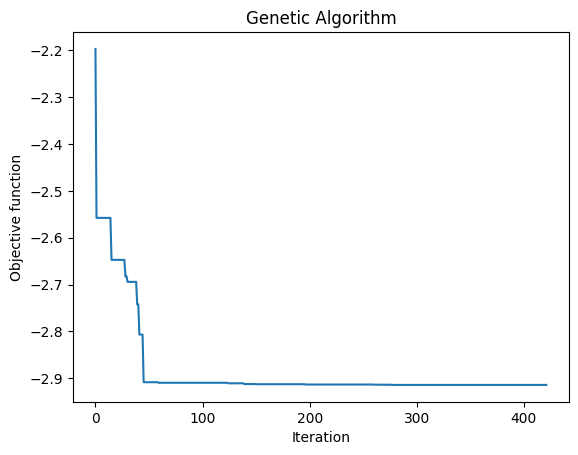



Wektor A =  [ 0.30851672  0.00212479 -0.39520907 -0.72359375]

f(A) =  2.914405052008564


In [ ]:
# Uruchamianie modelu (algorytmu)

model.run()

# Wizualizacja

result.append(-model.output_dict['function'])

print("\n\nWektor A = ", model.output_dict['variable'])
print("\nf(A) = ", -model.output_dict['function'])

Zbieranie kolejnych wyników w celu łatwiejszej analizy rozwiązań zadania.

In [ ]:
result = np.array(result).tolist()
print(result)

[2.915953849796862, 2.915496084595716, 2.9157881217999333, 2.914405052008564]


###**Zad. 2.** Korzystając z biblioteki *geneticalgorithm* napisz program w *Python* implementujący algorytm ewolucyjny do znajdowania minimum kosztów obsługi trasy autobusowej z uwzglednieniem ceny biletu.
### Przeanalizuj zmiany funkcji kosztów.

In [ ]:
!pip install geneticalgorithm

import numpy as np
from geneticalgorithm import geneticalgorithm as ga

Zakres dziedziny zagadnienia oraz parametry inicjujące biblioteki geneticalgorithm.

In [ ]:
# Założenia biznesowe, przestrzeń rozwiązań

bound = np.array([[1, 10],    # Liczba busów
                  [1, 30],    # Liczba kursów dziennie
                  [10, 400],  # Liczba pasażerow
                  [1, 30]])   # Cena biletu


# Definicje parametrów algorytmu

param = {
  'max_num_iteration': 2000,
  'population_size': 200,
  'mutation_probability': 0.01,
  'elit_ratio': 0.2,
  'crossover_probability': 0.8,
  'parents_portion': 0.3,
  'crossover_type': 'two_point',
  'max_iteration_without_improv': 500,
  'selection_type': 'tournament',
  'tournament_size': 3
  # 'display': False
}


Wynik analizy biznesowej: ilość busów, ilość kursów, szacowana liczba pasażerów, cena biletu. Delej - czynniki stałe: cena busa, koszty amortyzacji, cena paliwa, pensja pracowników, dystans trasy, pojemność busa oraz przewidywane kary. Na tej podstawie obliczamy przewidywany zysk, tzn. przechód minus koszty i zwracamy jako zagadnienie do minimalizacji. Stąd profit jest ujemny, bo dążymy do maksymalizacji zysku.

In [ ]:
# Funkcja celu - znalezienie maksymum funkcji

def func(x):

  # Wektor zmiennych

  num_bus = int(x[0])
  num_kurs = int(x[1])
  num_pas = int(x[2])
  bilet_cena = int(x[3])


  # Czynniki stałe

  bus_cena = 400000
  bus_lifetime = 500000
  koszt_amortyzacji_km = bus_cena / bus_lifetime
  koszt_personel_km = 2
  koszt_paliwo_km = 0.5
  dystans_km = 30
  bus_pojemnosc = 18
  kara_pas = 10


  # Koszty

  amortyzacja = num_bus * num_kurs * dystans_km * koszt_amortyzacji_km
  personel = num_bus * num_kurs * dystans_km * koszt_personel_km
  total = amortyzacja + personel
  paliwo = num_bus * num_kurs * dystans_km * koszt_paliwo_km

  # Przychody i kary

  max_pas = num_bus * num_kurs * bus_pojemnosc
  served_pas = min(num_pas, max_pas)
  unserved_pas = max(0, num_pas - max_pas)
  kara = unserved_pas * kara_pas
  przychod = served_pas * bilet_cena



  # Funkcja celu - maksymalizacja zysków
  # Przychód minus wydatki

  profit = przychod - (total + paliwo + kara)

  return -profit


Algorytm na podstawie funkcji celu zwróci 4 parametry: ilość busów, liczbę kursów, ilość pasażerów oraz cenę biletu przy maksymalizacji zysku.

Definicja i uruchomienie modelu z biblioteki 'geneticalgorithm' - wariant 1: Pojedynczy wynik.

 The best solution found:
 [  2.          11.         396.          29.55022882]

 Objective function:
 -9306.0


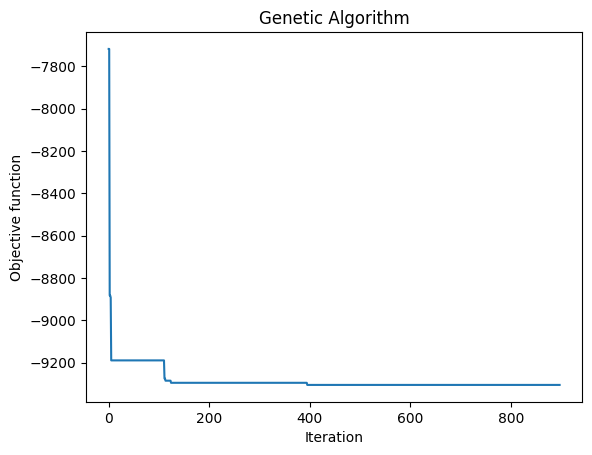



Optymalny wynik biznesowy:
Liczba busów: 2.0
Liczba kursów: 11.0
Liczba pasażerów: 396.0
Cena biletu: 29.55 PLN
Przychód: 9306.00 PLN


In [ ]:
# Definicje parametrów bibiloteki 'geneticalgorithm'

model = ga(
  function = func,
  dimension = 4,
  variable_type_mixed = np.array([['int'], ['int'], ['int'], ['real']]),
  variable_boundaries = bound,
  algorithm_parameters = param,
  convergence_curve = True
)

# Uruchomienie algorytmu w wersji 1

model.run()


a, b, c, d = model.output_dict['variable']
print("\n\nOptymalny wynik biznesowy:")
print(f"Liczba busów: {a}")
print(f"Liczba kursów: {b}")
print(f"Liczba pasażerów: {c}")
print(f"Cena biletu: {d:.2f} PLN")
print(f"Przychód: {-model.output_dict['function']:.2f} PLN")

Definicja i uruchomienie modelu z biblioteki 'geneticalgorithm' - wariant 2: Kolekcja 3 wyników, w celu ułatwienia analizy rozwiązań.

In [ ]:
# Uruchomienie algorytmu - 3 kolejno obliczonych wariantów

model = ga(
  function = func,
  dimension = 4,
  variable_type_mixed = np.array([['int'], ['int'], ['int'], ['real']]),
  variable_boundaries = bound,
  algorithm_parameters = param,
  convergence_curve = False
)

for i in range(3):
  model.run()
  a, b, c, d = model.output_dict['variable']
  print("\n\nOptymalny wynik biznesowy:")
  print(f"Liczba busów: {a}")
  print(f"Liczba kursów: {b}")
  print(f"Liczba pasażerów: {c}")
  print(f"Cena biletu: {d:.2f} PLN")
  print(f"Przychód: {-model.output_dict['function']:.2f} PLN")

 The best solution found:
 [  2.          11.         396.          29.21025426]

 Objective function:
 -9306.0


Optymalny wynik biznesowy:
Liczba busów: 2.0
Liczba kursów: 11.0
Liczba pasażerów: 396.0
Cena biletu: 29.21 PLN
Przychód: 9306.00 PLN
 The best solution found:
 [  1.          21.         378.          29.66597206]

 Objective function:
 -8883.0


Optymalny wynik biznesowy:
Liczba busów: 1.0
Liczba kursów: 21.0
Liczba pasażerów: 378.0
Cena biletu: 29.67 PLN
Przychód: 8883.00 PLN
 The best solution found:
 [  4.           6.         400.          29.97870269]

 Objective function:
 -9224.0


Optymalny wynik biznesowy:
Liczba busów: 4.0
Liczba kursów: 6.0
Liczba pasażerów: 400.0
Cena biletu: 29.98 PLN
Przychód: 9224.00 PLN


Często powtarzający się wynik to sugestia, aby zakupić jeden bus i maksymalnie go wykorzystać - maksymalne wykorzystanie pojemności busów (400/18). Ale losowo powtarzają się wyniki nie oczywiste, np. algorytm wskazuje wykorzystanie 4 busów po 6 kursów - co oznacza inwestycję w tabor, zapewniając nie mniejsze zyski (wszystkie na poziomie ok. 9000 PLN). Algorytm też wskazuje, aby zaoferować maksymalną cenę biletu (ok. 30 PLN).

Aby rozwinąć problem można by dodać warunki czasu przejazdu, tak by mieć pewność, że bus jest w stanie obsłużyć wymaganą ilość kursów oraz dodać warunek, że ilość kursów dla busu powinny być parzyste - tzn. busy muszą na noc wrócić do bazy. Można by też zastanowić się nad ilością kierowców oraz ich warunkami pracy, jak czas na odpoczynek i przydział na obsługę konkretnych busów przez konkretnych kierowców.

Zagadnienie komplkuje się znacznie, gdy chcialibyśmy ustalić tabelę rozkładu jazdy.


###**Zad. 3.** Korzystając z biblioteki *geneticalgorithm* napisz program w *Python* implementujący algorytm ewolucyjny do optymalizacji wybranego procesu.

In [ ]:
!pip install geneticalgorithm

import numpy as np
from geneticalgorithm import geneticalgorithm as ga


Zadanie jest sformułowane w następujący sposób. Mam do czynienia z przygotowaniem pewnego preparatu o ściśle określonym składzie, będący połączeniem 3 substancji. Zadana jest cena każdego ze składników, minimalna zawatość w preparacie oraz jakość wynikająca z najlepszej kombinacji stężeń.

Cena: A = 1.75,  B = 2.9, C = 4.1

Minimalna zawartość:  A = 28%,  B = 11%, C = 40%

Kombinacja minimalnej jakości: 2A + 3B + C

Zadanie optymalizacji polega na znalezieniu najtańszego produktu przy zachowaniu jakości oraz minimalnych stężeń.

In [ ]:
# Definicja zakresu i prametrów zagadnienia

bound = np.array([[28, 100], [11, 100], [40, 100]])   # Zakres procentowy od min do 100%

ceny = np.array([1.75, 2.9, 4.1])                     # Ceny składników

min_jakosc = 200                                      # Wskaźnik jakości produktu

Definiujemy warunki nakładania kar (penalizacji), które przyjmują następującą postać:

1. Suma wszystkich preparatów daje pełny skład, tzn. 100%

2. Składniki są nieujemne (w rzeczywistości są one określone dolnym zakresem w zmiennej <bound> i są nie mniejsze niż odpowiednio - 28, 11, 40)

3. Jakość jest nie gorsza niż 2A + 3B + C

In [ ]:
# Ograniczenia - warunki


def const(x):
    A, B, C = x             # Przekazanie parametrów
    warunki = []            # Definicja tablicy do sumowania kar

    # Warunek kompletnego produktu - suma = 100%
    warunki.append(100 - (A + B + C))  # A + B + C <= 100, więc 100 - suma >= 0

    # Składniki nie mogą być ujemne
    warunki.extend([-A, -B, -C])   # A, B, C >= 0

    # Warunek jakości: 2A + 3B + C >= min_jakosc
    warunki.append((2 * A) + (3 * B) + C - min_jakosc)

    return warunki          # Funkcja zwraca złożenie powyższych warunków

Definicja funkcji celu. Przekazuje A, B, C oraz definiuje koszt - ilość x cena. Przypisuje w pętli karę każdego z przekroczonych warunków sumując je. Zwraca sumę kosztów i kar. Skoro dążymy do minimalizacji kosztów dodanie kary będzie zwiększało zwracaną wartość oddalając przyjęcie tego wyniku.

In [ ]:
# Funkcja oceny (celu)

def fit(x):
  A, B, C = x

  # Suma kosztów poszczególnych składników
  koszt = (A * ceny[0] + B * ceny[1] + C * ceny[2])


  kara = 0
  results = const(x)
  # Kara za każde przekroczenie parametrów ( kiedy const(x) < 0 )
  for c in results:
      if c < 0:
          kara += abs(c) * 1000  # Im większa kara tym większe restrykcje

  # Minimalizacja kosztów, stąd dodanie kary do jak najmniejszych kosztow
  return koszt + kara


Definicja parametrów algorytmu ewolucyjnego. Dość optymalnie wyznaczone na drodze prób i relacji czas wykonania do jakości wyniku. Poniżej także parametry obliczeniowe zagadnienia dla biblioteki geneticalgorithm.

In [ ]:
# Definicje parametrów algorytmu

param = {
  'max_num_iteration': 1000,            # Liczba pokoleń
  'population_size': 200,               # Wielkość populacji
  'mutation_probability': 0.2,          # Wskaźnik mutacji
  'elit_ratio': 0.2,                    # Ilość elitarnych osobników selekcji
  'crossover_type': 'two_point',        # Rodzaj krzyżowania
  'crossover_probability': 0.8,         # Wskaźnik krzyżowania
  'parents_portion': 0.3,               # Wskaźnik rodziców przekazujących geny
  'mutation_type': 'uniform',           # Mutacja jednolicie prawdopodobna
  'mutation_rate': 0.01,                # Wskaźnik mutacji
  'max_iteration_without_improv': 200,  # Ilość iteracji bez poprawy wyniku
  'selection_type': 'tournament',       # Rodzaj selekcji - turniejowa
  'tournament_size': 3                  # Ilość zawodników w turnieju
}


# Prametry uruchomieniowe biblioteki

model = ga(
  function = fit,                       # Funkcja celu
  dimension = 3,                        # Przestrzeń zagadnienia
  variable_type = 'real',               # Typ obliczeniowy
  variable_boundaries = bound,          # Zakres rozwiązań
  algorithm_parameters = param,         # Definicja parametrów
  convergence_curve = False             # Bez Wyświetlania wykresu zbieżności

)


Uruchomienie obliczeń modelu oraz prezentacja wyników działania algorytmu. Wyniki zostały znormalizowane tak, aby wyświetlana procentowa suma stężeń była dokładną wartością 100%. Wyświetlono także koszt przygotowania oraz finalną jakość produktu.

In [ ]:

model.run()

A_opt, B_opt, C_opt = model.output_dict['variable']
suma = A_opt + B_opt + C_opt

# Normalizacja, jeśli suma różni się od 100%

A_pct = (A_opt / suma) * 100
B_pct = (B_opt / suma) * 100
C_pct = (C_opt / suma) * 100

# Wyznaczenie całkowitego kosztu oraz otrzymanej jakości

koszt_all = (A_pct/100 * ceny[0] + B_pct/100 * ceny[1] + C_pct/100 * ceny[2]) * 100 # Koszt - udział procentowy x 100
jakosc_all = 2*A_pct + 3* B_pct + C_pct

# Prezentacja wyników

print("\n\nOptymalne proporcje składników (w %):")
print(f"A: {A_pct:.2f}%")
print(f"B: {B_pct:.2f}%")
print(f"C: {C_pct:.2f}%")

print(f"Koszt: {koszt_all:.2f} PLN")
print(f"Jakość:  {jakosc_all:.2f}")

 The best solution found:
 [28.00435995 34.66104565 40.0031112 ]

 Objective function:
 105655.6029737009


Optymalne proporcje składników (w %):
A: 27.28%
B: 33.76%
C: 38.96%
Koszt: 305.39 PLN
Jakość:  194.80


Co do dyskusji wyników - algorytm daje (bardzo) dabre wyniki, choć wartości obliczone są czasem lekko niedoszacowane, jednak dobrze przybliżone. Program daje dobry pogląd na przygotowanie mieszanki substancji, gdzie priorytet nad ceną ma jakość. Wyniki też są powtarzalne, co wskazuje na dobrą jakość obliczeń i dobór parametrów algorytmu. Sam algorytm w śrosowisku colab wyznacza rozwiązanie w ciągu ok. 40 sekund. Zbieżność zaś ustala się w ciągu ok. 500 iteracji.